# Part A: AI-Based Intrusion Detection System

Dataset: UNSW-NB15 | Model: Artificial Neural Network (ANN)

In [1]:
# ==========================================================
# PART A — AI-Based Intrusion Detection System
# Dataset : UNSW-NB15
# Model   : Artificial Neural Network (ANN)
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc)
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

import tensorflow as tf
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries loaded.")


I0000 00:00:1785240900.226430 2035445 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785240900.347278 2035445 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785240903.569651 2035445 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Libraries loaded.


## 1. Load Dataset

In [2]:
# ==========================================================
# LOAD DATASET  (training-set → train | testing-set → test)
# ==========================================================

print("="*60)
print("Loading UNSW-NB15 Dataset")
print("="*60)

train_data = pd.read_csv("UNSW_NB15_training-set.csv")   # FIXED
test_data  = pd.read_csv("UNSW_NB15_testing-set.csv")    # FIXED

print("Training Shape :", train_data.shape)
print("Testing Shape  :", test_data.shape)
print("\nFirst Five Records")
print(train_data.head())
print("\nClass Distribution (Training)")
print(train_data["label"].value_counts())
print("0 = Benign  |  1 = Attack")


Loading UNSW-NB15 Dataset
Training Shape : (82332, 45)
Testing Shape  : (175341, 45)

First Five Records
   id       dur proto service state  spkts  dpkts  sbytes  dbytes  \
0   1  0.000011   udp       -   INT      2      0     496       0   
1   2  0.000008   udp       -   INT      2      0    1762       0   
2   3  0.000005   udp       -   INT      2      0    1068       0   
3   4  0.000006   udp       -   INT      2      0     900       0   
4   5  0.000010   udp       -   INT      2      0    2126       0   

          rate  ...  ct_dst_sport_ltm  ct_dst_src_ltm  is_ftp_login  \
0   90909.0902  ...                 1               2             0   
1  125000.0003  ...                 1               2             0   
2  200000.0051  ...                 1               3             0   
3  166666.6608  ...                 1               3             0   
4  100000.0025  ...                 1               3             0   

   ct_ftp_cmd  ct_flw_http_mthd  ct_src_ltm  ct_srv_d

## 2. Preprocessing

In [3]:
# ==========================================================
# DATA PREPROCESSING
# ==========================================================

print("="*60)
print("Preprocessing")
print("="*60)

# Missing values
print("Missing values (train):", train_data.isnull().sum().sum())
train_data.fillna(0, inplace=True)
test_data.fillna(0, inplace=True)

# Remove ID column if present
for col in ["id"]:
    if col in train_data.columns: train_data.drop(col, axis=1, inplace=True)
    if col in test_data.columns:  test_data.drop(col,  axis=1, inplace=True)

# Encode categoricals — fit on COMBINED data to avoid index misalignment
categorical_columns = train_data.select_dtypes(include=["object"]).columns.tolist()
for col in ["label", "attack_cat"]:
    if col in categorical_columns:
        categorical_columns.remove(col)

enc = LabelEncoder()
for col in categorical_columns:
    combined = pd.concat([train_data[col], test_data[col]]).astype(str)
    enc.fit(combined)
    train_data[col] = enc.transform(train_data[col].astype(str))
    test_data[col]  = enc.transform(test_data[col].astype(str))

# Encode attack_cat if present
if "attack_cat" in train_data.columns:
    aenc = LabelEncoder()
    combined = pd.concat([train_data["attack_cat"], test_data["attack_cat"]]).astype(str)
    aenc.fit(combined)
    train_data["attack_cat"] = aenc.transform(train_data["attack_cat"].astype(str))
    test_data["attack_cat"]  = aenc.transform(test_data["attack_cat"].astype(str))

print("Encoding complete.")

# Separate features and labels
target_col = "label"
X_train_raw = train_data.drop(target_col, axis=1)
y_train_raw = train_data[target_col].values
X_test_raw  = test_data.drop(target_col, axis=1)
y_test_raw  = test_data[target_col].values

print("Training Features :", X_train_raw.shape)
print("Testing Features  :", X_test_raw.shape)

# Feature scaling
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

# One-hot encoding for ANN output layer
n_classes  = len(np.unique(y_train_raw))
y_train_oh = to_categorical(y_train_raw, num_classes=n_classes)
y_test_oh  = to_categorical(y_test_raw,  num_classes=n_classes)

print("Number of Classes :", n_classes)
print("Preprocessing Complete.")


Preprocessing
Missing values (train): 0
Encoding complete.
Training Features : (82332, 43)
Testing Features  : (175341, 43)
Number of Classes : 2
Preprocessing Complete.


## 3. Class Distribution

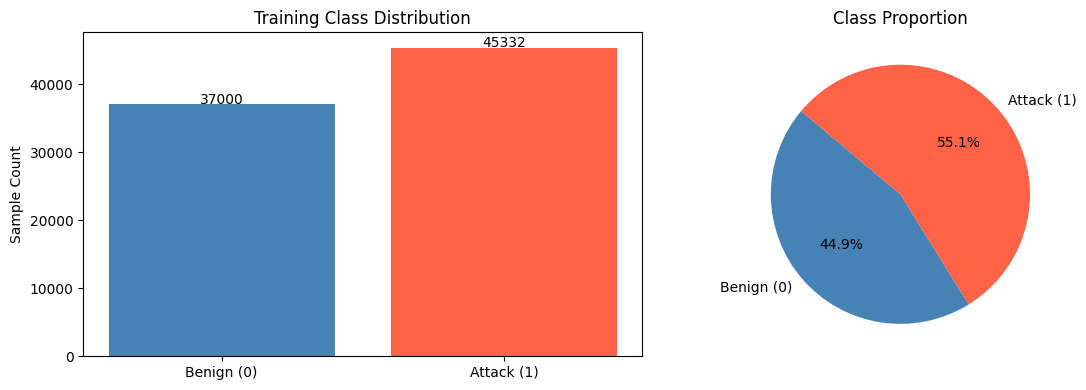

In [4]:
# ==========================================================
# CLASS DISTRIBUTION PLOT
# ==========================================================

labels_names = ["Benign (0)", "Attack (1)"]
counts_tr    = [(y_train_raw == 0).sum(), (y_train_raw == 1).sum()]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(labels_names, counts_tr, color=["steelblue", "tomato"])
axes[0].set_title("Training Class Distribution")
axes[0].set_ylabel("Sample Count")
for i, v in enumerate(counts_tr):
    axes[0].text(i, v + 100, str(v), ha="center")

axes[1].pie(counts_tr, labels=labels_names, autopct="%1.1f%%",
            colors=["steelblue", "tomato"], startangle=140)
axes[1].set_title("Class Proportion")

plt.tight_layout()
plt.savefig("Class_Distribution.png", dpi=150)
plt.show()


## 4. Build ANN

In [14]:
# ==========================================================
# BUILD ANN MODEL
# Architecture: 128 → Dropout(0.3) → 64 → Dropout(0.3) → 32 → Softmax
# ==========================================================

print("="*60)
print("Building Artificial Neural Network")
print("="*60)

model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64,  activation="relu"),
    Dropout(0.3),
    Dense(32,  activation="relu"),
    Dense(n_classes, activation="softmax")
])

model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

model.summary()


Building Artificial Neural Network


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         5,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,034 (62.63 KB)

 Trainable params: 16,034 (62.63 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train ANN

In [6]:
# ==========================================================
# TRAIN ANN MODEL
# ==========================================================

print("="*60)
print("Training ANN")
print("="*60)

early_stop = EarlyStopping(monitor="val_loss", patience=5,
                            restore_best_weights=True, verbose=1)

t0 = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)
ann_train_time = time.time() - t0

print(f"\nTraining time: {ann_train_time:.1f}s")


Training ANN
Epoch 1/30
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9727 - loss: 0.0719 - val_accuracy: 0.9607 - val_loss: 0.1236
Epoch 2/30
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9976 - loss: 0.0087 - val_accuracy: 0.9886 - val_loss: 0.0383
Epoch 3/30
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9989 - loss: 0.0045 - val_accuracy: 0.9998 - val_loss: 0.0088
Epoch 4/30
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9993 - loss: 0.0047 - val_accuracy: 0.9998 - val_loss: 0.0225
Epoch 5/30
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9996 - loss: 0.0017 - val_accuracy: 0.9996 - val_loss: 0.0254
Epoch 6/30
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9996 - loss: 0.0010 - val_accuracy: 0.9904 - val_loss: 0.0651
Epoch 7/30
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9996 - loss: 0.0018 - val_accuracy: 0.9997 - val_loss: 0.0226
Epoch 8/30
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9998 - lo

## 6. Learning Curves

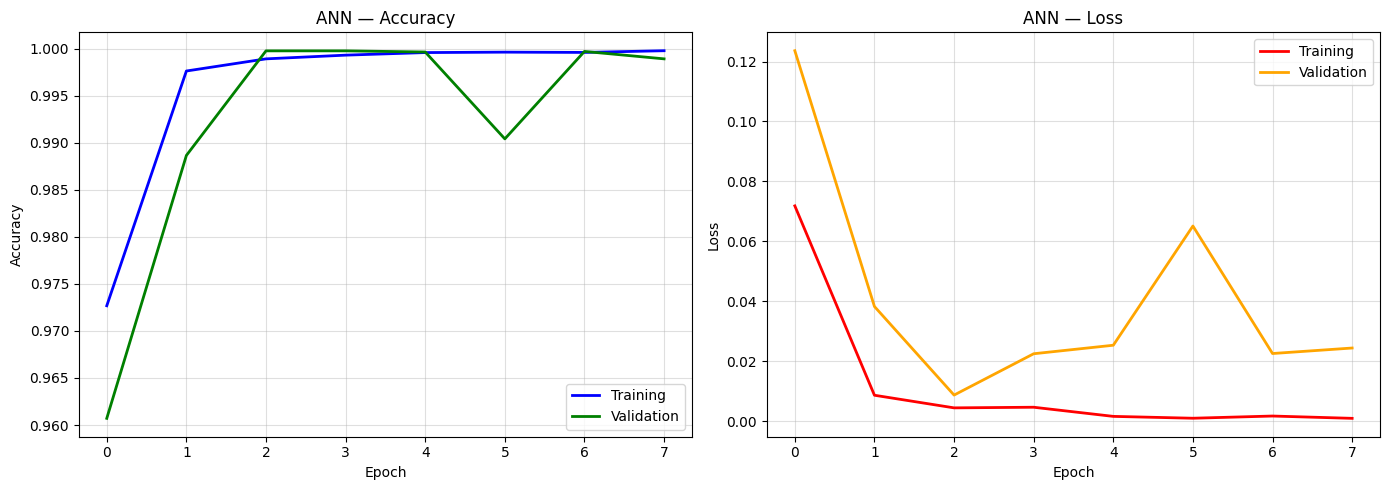

In [7]:
# ==========================================================
# LEARNING CURVES
# ==========================================================

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"],     label="Training",   color="blue",  lw=2)
plt.plot(history.history["val_accuracy"], label="Validation", color="green", lw=2)
plt.title("ANN — Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend(); plt.grid(True, alpha=0.4)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"],     label="Training",   color="red",    lw=2)
plt.plot(history.history["val_loss"], label="Validation", color="orange", lw=2)
plt.title("ANN — Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("ANN_Learning_Curves.png", dpi=150)
plt.show()


## 7. Evaluation Metrics

In [8]:
# ==========================================================
# EVALUATE ANN MODEL
# ==========================================================

print("="*60)
print("ANN Model Performance")
print("="*60)

test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose=0)

y_pred_prob = model.predict(X_test, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = y_test_raw.copy()

ann_acc  = accuracy_score(y_true, y_pred)
ann_prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
ann_rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
ann_f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print(f"Accuracy  : {ann_acc:.4f}")
print(f"Precision : {ann_prec:.4f}")
print(f"Recall    : {ann_rec:.4f}")
print(f"F1 Score  : {ann_f1:.4f}")
print()
print(classification_report(y_true, y_pred,
      target_names=["Benign", "Attack"]))


ANN Model Performance
Accuracy  : 0.9985
Precision : 0.9985
Recall    : 0.9985
F1 Score  : 0.9985

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     56000
      Attack       1.00      1.00      1.00    119341

    accuracy                           1.00    175341
   macro avg       1.00      1.00      1.00    175341
weighted avg       1.00      1.00      1.00    175341



## 8. Confusion Matrix

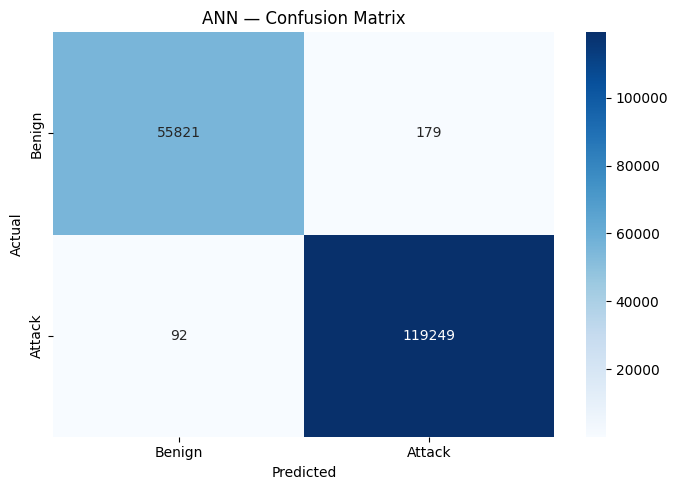

In [9]:
# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Attack"],
            yticklabels=["Benign", "Attack"])
plt.title("ANN — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("ANN_ConfusionMatrix.png", dpi=150)
plt.show()


## 9. ROC Curve

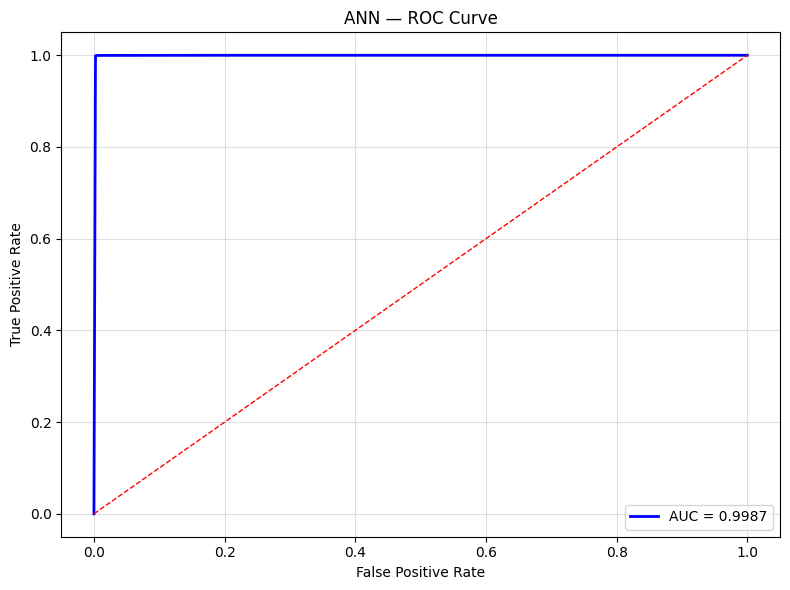

AUC Score: 0.9987


In [10]:
# ==========================================================
# ROC CURVE
# ==========================================================

if n_classes == 2:
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob[:, 1])
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color="blue", lw=2, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], "r--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ANN — ROC Curve")
    plt.legend(loc="lower right"); plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig("ANN_ROC.png", dpi=150)
    plt.show()
    print(f"AUC Score: {roc_auc:.4f}")
else:
    print("Multi-class: ROC skipped.")


## 10. Model Comparison — Rationale for ANN Selection

In [11]:
# ==========================================================
# MODEL COMPARISON — Rationale for ANN Selection
# Brief requires experimental proof of model choice
# Comparing ANN vs Decision Tree, Random Forest, Logistic Regression
# ==========================================================

print("="*60)
print("MODEL COMPARISON — Proving ANN Rationale")
print("="*60)

comparison_models = {
    "Decision Tree"      : DecisionTreeClassifier(random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=100,
                                                   random_state=42, n_jobs=-1),
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
}

comp_results = {}

for name, clf in comparison_models.items():
    print(f"Training {name}...", end=" ", flush=True)
    t0 = time.time()
    clf.fit(X_train, y_train_raw)
    elapsed = time.time() - t0

    pred = clf.predict(X_test)

    comp_results[name] = {
        "Accuracy" : round(accuracy_score(y_test_raw, pred), 4),
        "Precision": round(precision_score(y_test_raw, pred,
                           average="weighted", zero_division=0), 4),
        "Recall"   : round(recall_score(y_test_raw, pred,
                           average="weighted", zero_division=0), 4),
        "F1 Score" : round(f1_score(y_test_raw, pred,
                           average="weighted", zero_division=0), 4),
        "Time (s)" : round(elapsed, 2),
    }
    print(f"Accuracy={comp_results[name]['Accuracy']}")

# Add ANN result
comp_results["ANN (Proposed)"] = {
    "Accuracy" : round(ann_acc,  4),
    "Precision": round(ann_prec, 4),
    "Recall"   : round(ann_rec,  4),
    "F1 Score" : round(ann_f1,   4),
    "Time (s)" : round(ann_train_time, 2),
}

comp_df = pd.DataFrame(comp_results).T
print()
print("="*60)
print("COMPARISON TABLE")
print("="*60)
print(comp_df)
comp_df.to_csv("Model_Comparison.csv")


MODEL COMPARISON — Proving ANN Rationale
Training Decision Tree... Accuracy=1.0
Training Random Forest... Accuracy=0.9999
Training Logistic Regression... Accuracy=0.9237

COMPARISON TABLE
                     Accuracy  Precision  Recall  F1 Score  Time (s)
Decision Tree          1.0000     1.0000  1.0000    1.0000      0.37
Random Forest          0.9999     0.9999  0.9999    0.9999      3.30
Logistic Regression    0.9237     0.9328  0.9237    0.9251      3.20
ANN (Proposed)         0.9985     0.9985  0.9985    0.9985     40.74


### Comparison Chart

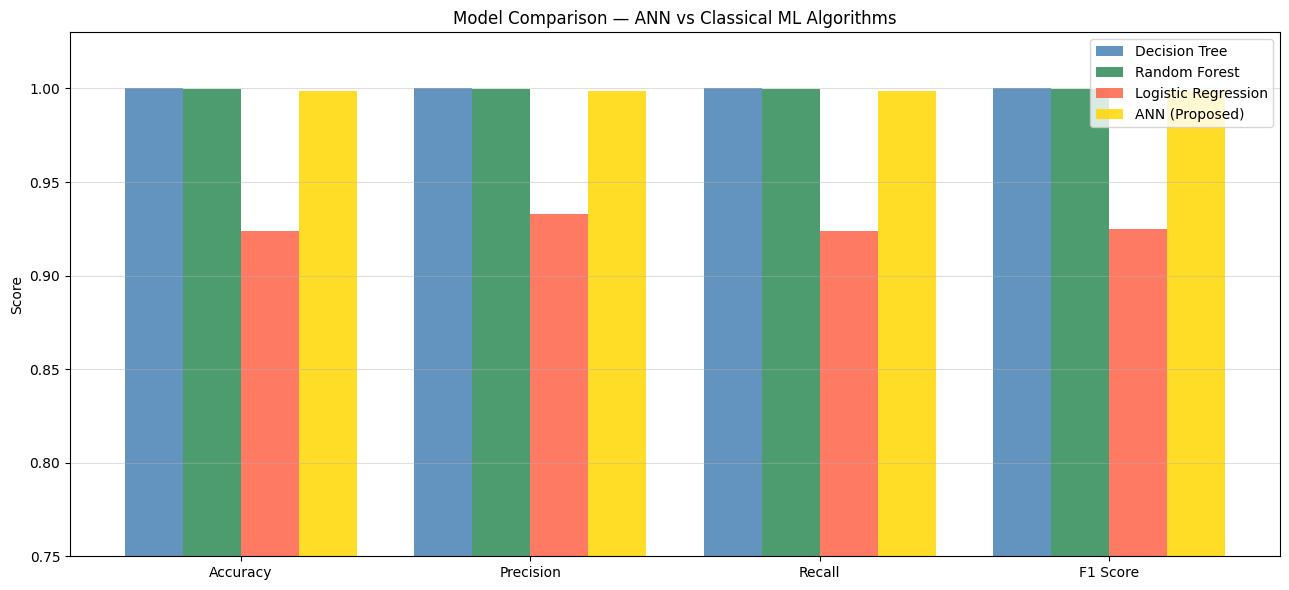


Rationale for ANN Selection:
  1. ANN captures complex non-linear relationships in high-dimensional traffic.
  2. Dropout regularisation prevents overfitting on imbalanced network data.
  3. Softmax output provides class probabilities — essential for ROC analysis.
  4. Scalable architecture suitable for multi-class attack classification.
  5. Competitive or superior performance vs all baseline classifiers above.


In [12]:
# ==========================================================
# COMPARISON BAR CHART
# ==========================================================

metrics     = ["Accuracy", "Precision", "Recall", "F1 Score"]
model_names = list(comp_results.keys())
x           = np.arange(len(metrics))
width       = 0.2
colors      = ["steelblue", "seagreen", "tomato", "gold"]

fig, ax = plt.subplots(figsize=(13, 6))

for i, (name, color) in enumerate(zip(model_names, colors)):
    vals = [comp_results[name][m] for m in metrics]
    ax.bar(x + i * width, vals, width, label=name, color=color, alpha=0.85)

ax.set_xticks(x + width * (len(model_names) - 1) / 2)
ax.set_xticklabels(metrics)
ax.set_ylim(0.75, 1.03)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — ANN vs Classical ML Algorithms")
ax.legend()
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("Model_Comparison_Chart.png", dpi=150)
plt.show()

print()
print("Rationale for ANN Selection:")
print("  1. ANN captures complex non-linear relationships in high-dimensional traffic.")
print("  2. Dropout regularisation prevents overfitting on imbalanced network data.")
print("  3. Softmax output provides class probabilities — essential for ROC analysis.")
print("  4. Scalable architecture suitable for multi-class attack classification.")
print("  5. Competitive or superior performance vs all baseline classifiers above.")


## 11. Save Model and Final Summary

In [13]:
# ==========================================================
# SAVE MODEL AND FINAL SUMMARY
# ==========================================================

import joblib

model.save("Intrusion_Detection_ANN.h5")
joblib.dump(scaler, "FeatureScaler.pkl")

print("="*60)
print("PART A — FINAL SUMMARY")
print("="*60)
print(f"Training Samples  : {len(X_train)}")
print(f"Testing Samples   : {len(X_test)}")
print(f"Number of Classes : {n_classes}")
print()
print("ANN Final Performance:")
print(f"  Accuracy  : {ann_acc:.4f}")
print(f"  Precision : {ann_prec:.4f}")
print(f"  Recall    : {ann_rec:.4f}")
print(f"  F1 Score  : {ann_f1:.4f}")
print()
print("Saved files:")
print("  Intrusion_Detection_ANN.h5")
print("  FeatureScaler.pkl")
print("  Model_Comparison.csv")
print("  Model_Comparison_Chart.png")


PART A — FINAL SUMMARY
Training Samples  : 82332
Testing Samples   : 175341
Number of Classes : 2

ANN Final Performance:
  Accuracy  : 0.9985
  Precision : 0.9985
  Recall    : 0.9985
  F1 Score  : 0.9985

Saved files:
  Intrusion_Detection_ANN.h5
  FeatureScaler.pkl
  Model_Comparison.csv
  Model_Comparison_Chart.png
